In [1]:
import os
import numpy as np
import ase
from ase import Atoms
from ase import io
from ase.io.espresso import write_espresso_in as write_in
from ase.io.espresso import read_espresso_out as read_out
from ase.io.lammpsdata import write_lammps_data
from ase.io.lammpsdata import read_lammps_data
from ase.io.lammpsrun import read_lammps_dump_text
from ase.io import write
from ase.io import read
from ase.calculators.espresso import Espresso
from ase.build import make_supercell
from ase.build import surface
from ase.build import sort
from ase.constraints import FixAtoms

In [2]:
# 1. Added index=-1 to get the optimized result, not the starting point
bulk = read('./../bulk_optimization/pw.out',format='espresso-out', index=-1) 

# 2. Define the 2x2x2 expansion matrix
P = [[2, 0, 0], [0, 2, 0], [0, 0, 2]]

# 3. Generate the supercell
conf = make_supercell(bulk, P)

# 4. Write to file
write('./bulk_Pt_supercell.extxyz',conf, format='extxyz')

print(f"Original atoms: {len(bulk)}")
print(f"Supercell atoms: {len(conf)}")

Original atoms: 4
Supercell atoms: 32


In [3]:
# --- 1. Paths ---
# Make sure to provide the correct path to your .extxyz file
extxyz_path = "./bulk_Pt_supercell.extxyz" 
outdir = "./"
pseudo_dir = "./../pseudo"
ecut=70
pseudopotentials = {'Pt': 'Pt_ONCV_PBE-1.2.upf'}
atoms = io.read(extxyz_path, format='extxyz')
ntyp = len(set(atoms.get_chemical_symbols()))
nat = len(atoms)
input_qe = {
            'control': {
                'calculation': 'scf',
                'outdir': './outdir',
                'pseudo_dir': pseudo_dir,
                'tprnfor': True,
                'disk_io': 'none',
                'restart_mode': 'from_scratch',
            },
            'system': {
                'ibrav': 0,
                'ntyp': ntyp,
                'nat': nat,
                'ecutwfc': ecut,
                'ecutrho': 4 * ecut,
                'input_dft': 'PBE',
                'nbnd': 346,
                'occupations': 'smearing', 
                'smearing': 'marzari-vanderbilt',
                'degauss': 0.02,
            },
            'electrons': {
                'mixing_beta': 0.1,
                'electron_maxstep': 200,
                'diagonalization': 'david',
                'conv_thr': 1e-06,
                'mixing_ndim': 8,
            },
        }
# --- 2. Define the Mapping for 5-8 ---
# (K-points, Offset)
k_configs = {
    1: ((2, 2, 2), (0, 0, 0)),
    2: ((4, 4, 4), (0, 0, 0)),
    3: ((6, 6, 8), (0, 0, 0)),
    4: ((8, 8, 8), (0, 0, 0)),
}

# --- 3. Load the structure from .extxyz ---
conf = ase.io.read(extxyz_path)

# --- 4. Generation Loop ---
for trial_id, (kpts, offset) in k_configs.items():
    current_iteration_dir = os.path.join(outdir, f'trial_{trial_id}', 'scf_0')
    
    if not os.path.exists(current_iteration_dir):
        os.makedirs(current_iteration_dir, exist_ok=True)
    
    output_file_path = os.path.join(current_iteration_dir, 'pw.in')
    
    # Write the QE input file
    write(output_file_path, conf, format='espresso-in', 
          input_data=input_qe, 
          pseudopotentials=pseudopotentials, 
          kpts=kpts, 
          offset=offset)
    
    # Generate the SLURM submission script (qe.sub)
    sub_script_path = os.path.join(current_iteration_dir, "qe.sub")
    with open(sub_script_path, "w") as f:
        f.write(f"""#!/bin/bash
#SBATCH --job-name=scf_{trial_id}
#SBATCH --nodes=2
#SBATCH --ntasks-per-node=48
#SBATCH --partition=standard
#SBATCH --time=06:00:00
mpirun -np 96 -mca coll_hcoll_enable 0 $HOME/qe-6.7/bin/pw.x -npool 2 -in pw.in > pw.out
rm -r outdir
""")

print(f"Successfully generated Trials using {extxyz_path}")

# --- 4. Create the Master submit.sh script ---
# This will be created in your 'outdir'
submit_sh_path = os.path.join(outdir, "submit.sh")

submit_sh_content = f"""#!/bin/bash
# Master submit script generated by Python
# This finds every qe.sub in the subdirectories and submits them

BASE_DIR="{outdir}"

# Use find to catch qe.sub even if they are inside scf_0 subfolders
find "$BASE_DIR" -name "qe.sub" | while read sub_file; do
    dir=$(dirname "$sub_file")
    echo "Submitting job in $dir"
    
    # Use -D to tell sbatch to run FROM that directory
    sbatch -D "$dir" "$sub_file"
done

echo "All jobs submitted. Check status with: squeue -u $USER"
"""

# Write the master submit script
with open(submit_sh_path, "w") as f:
    f.write(submit_sh_content)

# Make the submit script executable automatically
os.chmod(submit_sh_path, 0o755)

print(f"\n--- SUCCESS ---")
print(f"1. Folders and qe.sub files created in {outdir}")
print(f"2. Master submit script created at: {submit_sh_path}")
print(f"To run everything, simply type: {submit_sh_path}")

Successfully generated Trials using ./bulk_Pt_supercell.extxyz

--- SUCCESS ---
1. Folders and qe.sub files created in ./
2. Master submit script created at: ./submit.sh
To run everything, simply type: ./submit.sh


--- Reading Results from Trials ---
Trial 1 (2×2×2): -105631.012472 eV
Trial 2 (4×4×4): -105632.094706 eV
Trial 3 (6×6×6): -105632.080152 eV
Trial 4 (8×8×8): -105632.079050 eV

Success! Plot saved to: ./Pt_supercell_kpointsconvergence.png


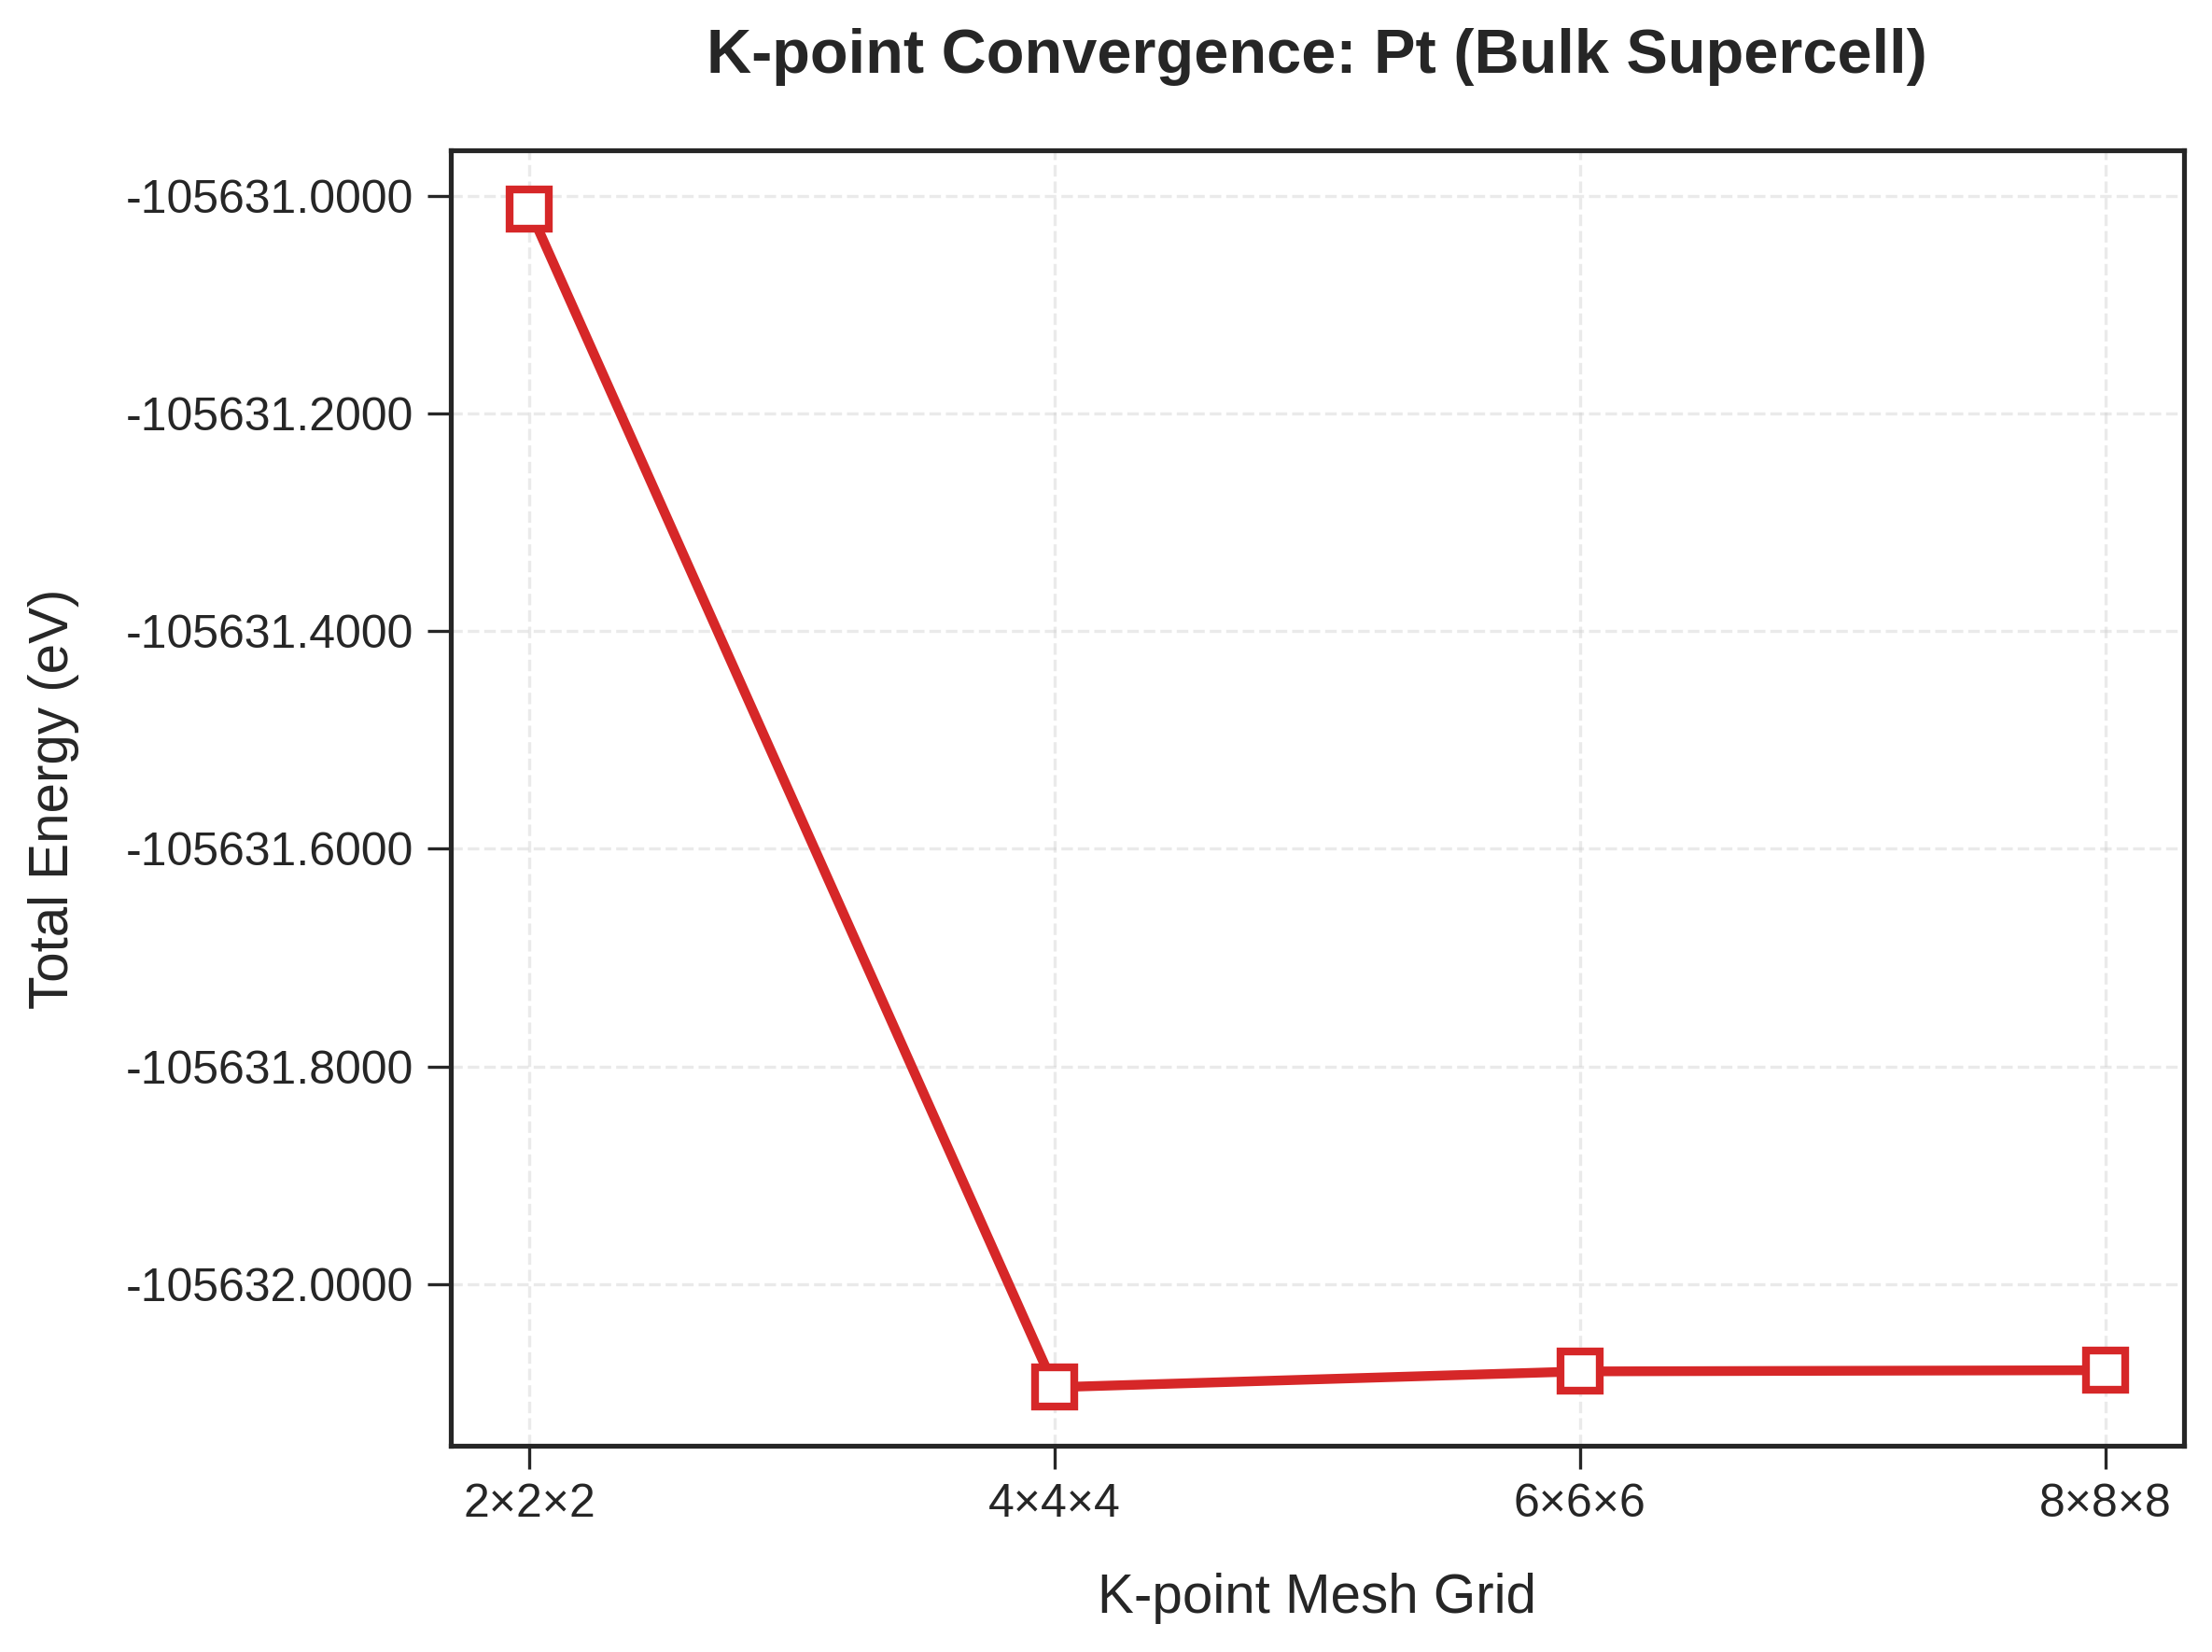

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ase import io
import os

# --- 1. Configuration ---
outdir_base = "./"
trial_ids = [1, 2, 3, 4]
kpoints_labels = ['2×2×2', '4×4×4', '6×6×6', '8×8×8']

potential_energy = []
valid_labels = []

print("--- Reading Results from Trials ---")

# --- 2. Data Extraction ---
for idx, t_id in enumerate(trial_ids):
    out_path = os.path.join(outdir_base, f'trial_{t_id}', 'scf_0', 'pw.out')
    
    if os.path.exists(out_path):
        try:
            # index=-1 ensures we get the final energy if it was a relaxation
            conf = io.read(out_path, format='espresso-out', index=-1)
            energy = conf.get_potential_energy()
            potential_energy.append(energy)
            valid_labels.append(kpoints_labels[idx])
            print(f"Trial {t_id} ({kpoints_labels[idx]}): {energy:.6f} eV")
        except Exception as e:
            print(f"Could not read Trial {t_id}: {e}")
    else:
        print(f"File missing: {out_path}")

# --- 3. Publication Quality Plotting ---
if potential_energy:
    # Set the style
    plt.style.use('seaborn-v0_8-ticks') 
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    # Plotting with Red Color Scheme
    ax.plot(valid_labels, potential_energy, 
            marker='s',           # Square markers
            markersize=10, 
            markerfacecolor='white', 
            markeredgewidth=2,
            linestyle='-', 
            linewidth=2.5, 
            color='#d62728',      # Professional Red
            zorder=3)

    # --- 4. Remove Offset (The "+E" at the top) ---
    # This forces the Y-axis to show absolute numbers
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
    # Optional: Force 4 decimal places for consistency
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

    # --- 5. Labels and Titles ---
    ax.set_title(r'K-point Convergence: Pt (Bulk Supercell)', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('K-point Mesh Grid', fontsize=14, labelpad=12)
    ax.set_ylabel('Total Energy (eV)', fontsize=14, labelpad=12)

    # --- 6. Aesthetic Refinements ---
    ax.grid(True, which='major', linestyle='--', alpha=0.4, zorder=0)
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Remove top and right spines for a modern look
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)

    plt.tight_layout()
    
    # --- 7. Save Results ---
    save_path_png = os.path.join(outdir_base, "Pt_supercell_kpointsconvergence.png")
    plt.savefig(save_path_png, bbox_inches='tight')
    
    print(f"\nSuccess! Plot saved to: {save_path_png}")
    plt.show()
else:
    print("Error: No energy data was found. Check your pw.out files.")